In [2]:
import pandas as pd

outcome_df = pd.read_csv('../../Data/V4A.csv', usecols=['PublicID', 'V4AH01'], encoding='latin-1')
outcome_df['V4AH01'] = outcome_df['V4AH01'].replace('D', pd.NA)
outcome_df['V4AH01'] = pd.to_numeric(outcome_df['V4AH01'], errors='coerce')
outcome_df = outcome_df.drop_duplicates(subset=['PublicID'])
outcome_df['V4AH01'].value_counts() # 1 - breast feed only, 2 - bottle feed only, 3 - both

V4AH01
1.0    3042
3.0    1307
2.0     621
Name: count, dtype: int64

In [3]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))  # points to src/
from shared_modeling import (
    compute_hassles_uplifts,
    compute_resilience_score,
    compute_stress_average,
    compute_stress_level,
    run_model_experiment,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from imblearn.pipeline import Pipeline as ImbPipeline  # Use imblearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import shap

/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class AdaptiveSMOTE(SMOTE):
    def __init__(self, random_state=42, k_neighbors=5):
        super().__init__(random_state=random_state, k_neighbors=k_neighbors)

    def _fit_resample(self, X, y):
        class_counts = pd.Series(y).value_counts()
        minority_count = int(class_counts.min())
        if minority_count < 2:
            return X, y
        original_k_neighbors = self.k_neighbors
        self.k_neighbors = min(original_k_neighbors, minority_count - 1)
        try:
            return super()._fit_resample(X, y)
        finally:
            self.k_neighbors = original_k_neighbors

def create_pipeline(preprocessor, classifier, use_smote=True, poly_features=False, pca_components=None):
    steps = [('preprocessor', preprocessor)]
    
    if pca_components:
        steps.append(('pca', PCA(n_components=pca_components)))
    
    if poly_features:
        steps.append(('poly', PolynomialFeatures(degree=2, include_bias=False)))
        
    if use_smote:
        steps.append(('smote', AdaptiveSMOTE(random_state=42)))
        
    steps.append(('classifier', classifier))
    
    return ImbPipeline(steps=steps)

In [5]:
def get_feature_names_from_pipeline(model, X_train=None):
    """Return feature names after preprocessing when a pipeline is used."""
    if hasattr(model, 'named_steps') and 'preprocessor' in model.named_steps:
        try:
            return np.asarray(model.named_steps['preprocessor'].get_feature_names_out())
        except Exception:
            pass
    if X_train is not None:
        return np.asarray(X_train.columns)
    return None


def plot_confusion_matrix_for_model(model, X_test, y_test, labels=None, title='Confusion Matrix'):
    y_pred = model.predict(X_test)
    y_true = pd.Series(y_test).dropna()
    y_pred = pd.Series(y_pred)
    if labels is None:
        labels = np.unique(pd.concat([y_true, y_pred], ignore_index=True))
    else:
        labels = np.unique(np.concatenate([np.asarray(labels), np.unique(pd.concat([y_true, y_pred], ignore_index=True))]))
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_roc_curve_for_model(model, X_test, y_test, title='ROC Curve'):
    if not hasattr(model, 'predict_proba'):
        print('ROC curve skipped: model does not expose predict_proba().')
        return
    unique_classes = np.unique(pd.Series(y_test).dropna())
    if len(unique_classes) != 2:
        print('ROC curve skipped: multiclass targets are not plotted as a single ROC curve.')
        return
    y_score = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f"{title} (AUC={roc_auc_score(y_test, y_score):.3f})")
    plt.tight_layout()
    plt.show()


def plot_model_feature_importance(model, X_train=None, top_n=20, title='Feature Importance'):
    feature_names = get_feature_names_from_pipeline(model, X_train)
    classifier = model.named_steps['classifier'] if hasattr(model, 'named_steps') and 'classifier' in model.named_steps else model

    if hasattr(classifier, 'feature_importances_'):
        importances = classifier.feature_importances_
    elif hasattr(classifier, 'coef_'):
        importances = np.abs(np.ravel(classifier.coef_))
    else:
        print('Feature importance skipped: model does not expose coefficients or feature_importances_.')
        return None

    if feature_names is None:
        feature_names = np.array([f'feature_{i}' for i in range(len(importances))])
    else:
        feature_names = np.asarray(feature_names)[: len(importances)]
        importances = importances[: len(feature_names)]

    fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi = fi.sort_values('importance', ascending=False).head(top_n)
    plt.figure(figsize=(10, max(4, 0.35 * len(fi))))
    plt.barh(fi['feature'][::-1], fi['importance'][::-1])
    plt.title(title)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return fi


def plot_permutation_importance_for_model(model, X_test, y_test, top_n=20, title='Permutation Importance'):
    feature_names = np.asarray(X_test.columns) if hasattr(X_test, 'columns') else np.array([f'feature_{i}' for i in range(X_test.shape[1])]) if hasattr(X_test, 'shape') else get_feature_names_from_pipeline(model, X_test)
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

    if feature_names is None:
        feature_names = np.array([f'feature_{i}' for i in range(len(result.importances_mean))])
    else:
        feature_names = np.asarray(feature_names)[: len(result.importances_mean)]

    pi = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
    }).sort_values('importance_mean', ascending=False).head(top_n)

    plt.figure(figsize=(10, max(4, 0.35 * len(pi))))
    plt.barh(pi['feature'][::-1], pi['importance_mean'][::-1], xerr=pi['importance_std'][::-1])
    plt.title(title)
    plt.xlabel('Permutation Importance')
    plt.tight_layout()
    plt.show()
    return pi


def plot_shap_summary_for_model(model, X_train, X_test, max_display=20, sample_size=500):
    """Generate SHAP summary plots for tree-based or linear models when supported."""
    classifier = model.named_steps['classifier'] if hasattr(model, 'named_steps') and 'classifier' in model.named_steps else model
    feature_names = get_feature_names_from_pipeline(model, X_train)

    X_shap = X_test.sample(min(sample_size, len(X_test)), random_state=42) if len(X_test) > sample_size else X_test

    try:
        if hasattr(model, 'named_steps') and 'preprocessor' in model.named_steps:
            X_shap_transformed = model.named_steps['preprocessor'].transform(X_shap)
        else:
            X_shap_transformed = X_shap

        explainer = shap.Explainer(classifier, X_shap_transformed)
        shap_values = explainer(X_shap_transformed)
        shap.summary_plot(shap_values, X_shap_transformed, feature_names=feature_names, max_display=max_display, show=True)
        return shap_values
    except Exception as exc:
        print(f'SHAP skipped: {exc}')
        return None


def run_interpretability_suite(model, X_train, X_test, y_test, labels=None, top_n=20):
    """Run the standard combined-model interpretability outputs."""
    plot_confusion_matrix_for_model(model, X_test, y_test, labels=labels)
    plot_roc_curve_for_model(model, X_test, y_test)
    plot_model_feature_importance(model, X_train=X_train, top_n=top_n)
    plot_permutation_importance_for_model(model, X_test, y_test, top_n=top_n)
    plot_shap_summary_for_model(model, X_train, X_test, max_display=top_n)

In [6]:
# Maternal physical health features
maternal_physical_features = ['oDM', 'acog_PEgHTN', 'ChronHTN']  # pregnancy-related physical health predictors
df_maternal_physical = pd.read_csv('../../Data/PREGNANCY_OUTCOMES.csv', usecols=maternal_physical_features + ['PublicID'])

# Maternal mental health features
# Resilience (V2I)
v2i_cols = ['PublicID'] + [f'V2IA{i:02d}' for i in range(1, 26)]
df_v2i = pd.read_csv('../../Data/V2I.csv', usecols=v2i_cols)
# Stress average (V1E)
v1e_cols = ['PublicID', 'V1EA01', 'V1EA02a', 'V1EA02b', 'V1EA02c', 'V1EA02d', 'V1EA02e', 'V1EA02f', 'V1EA02g', 'V1EA02h', 'V1EA02i', 'V1EA02j', 'V1EA02k', 'V1EA02l']
df_v1e = pd.read_csv('../../Data/V1E.CSV', usecols=v1e_cols, encoding='ISO-8859-1')
# Hassle/uplift intensity and frequency ratios (V3J)
v3j_cols = ['PublicID'] + [f'V3JA01{letter}' for letter in 'abcdefghij'] + [f'V3JA02{letter}' for letter in 'abcdefghij']
df_v3j = pd.read_csv('../../Data/V3J.csv', usecols=v3j_cols)
# Stress level binning (V1A + V3A)
v1a_stress_cols = ['PublicID', 'V1AH04', 'V1AH05', 'V1AH07', 'V1AH08']
v3a_stress_cols = ['PublicID', 'V3AG04', 'V3AG05', 'V3AG07', 'V3AG08']
df_v1a_stress = pd.read_csv('../../Data/V1A.CSV', usecols=v1a_stress_cols)
df_v3a_stress = pd.read_csv('../../Data/V3A.CSV', usecols=v3a_stress_cols)

# Paternal demographics (Demo_father)
paternal_features = ['V2AF13', 'V2AF15']  # father's age and years of education
df_paternal = pd.read_csv('../../Data/V2A.csv', usecols=paternal_features + ['PublicID'], low_memory=False)
df_paternal[paternal_features] = df_paternal[paternal_features].replace({'R': np.nan, 'D': np.nan})
df_paternal[paternal_features] = df_paternal[paternal_features].apply(pd.to_numeric, errors='coerce')

# Drug use (Drugs)
drug_features = ['V2AH01', 'V2AH02', 'V2AH03', 'V2AH04', 'V2AH05', 'V2AH06']
df_drugs = pd.read_csv('../../Data/V2A.csv', usecols=drug_features + ['PublicID'], low_memory=False)
df_drugs = df_drugs.replace({'R': np.nan, 'D': np.nan})
df_drugs[drug_features] = df_drugs[drug_features].apply(pd.to_numeric, errors='coerce')

# Food / nutrition (Food_Model)
food_features = ['DT_FOLAC', 'DT_CALC', 'VITD_MCG', 'TOTAL_CHOLINE', 'DT_SODI', 'PRENATALYEARS', 'PRENATALAMOUNT', 'AHEI2010', 'AHEI_ALCDRKS', 'AHEI_SODIUM', 'AHEI_PUFAPCT', 'AHEI_DHAEPA', 'AHEI_TRFATPCT', 'AHEI_RMEATS', 'AHEI_NUTLEGS', 'AHEI_SUGBEVS', 'AHEI_WGRAINS', 'AHEI_FRUITS', 'AHEI_VEGS', 'DT_ALCO', 'DT_CAFFN', 'DT_FIBE', 'DT_SUG_T', 'DT_CHOL', 'DT_PFAT', 'DT_MFAT', 'DT_SFAT', 'DT_TFAT', 'DT_CARB', 'DT_KCAL', 'DT_PROT', 'DT_VITC', 'DT_VB12', 'DT_VITB6', 'DT_NIAC', 'DT_RIBO', 'DT_THIA', 'DT_IRON', 'DT_TOTN3']
df_food = pd.read_csv('../../Data/FOOD_FREQUENCY_ANALYSIS.csv', usecols=food_features + ['PublicID'])
df_food[food_features] = df_food[food_features].apply(pd.to_numeric, errors='coerce')

# Health knowledge (Health_knowledge_model)
health_knowledge_features = ['V1AD02a', 'V1AD02b', 'V1AD02c', 'V1AD02d', 'V1AD02e', 'V1AD02f', 'V1AD02g', 'V1AD02h', 'V1AD02i', 'V1AD02j', 'V1AD02k']
df_health_knowledge = pd.read_csv('../../Data/V1A.csv', usecols=health_knowledge_features + ['PublicID'])
df_health_knowledge[health_knowledge_features] = df_health_knowledge[health_knowledge_features].apply(pd.to_numeric, errors='coerce')

# Mother demographics (Mother_demo)
mother_numeric_features = ['Age_at_V1', 'V1AF02', 'V1AF10']  # age, years of education, English
mother_categorical_features = ['CRace', 'V1AF14']
df_mother_num = pd.read_csv('../../Data/V1A.CSV', usecols=['V1AF02', 'V1AF14', 'V1AF10', 'PublicID'], encoding='latin-1')
df_mother_demo = pd.read_csv('../../Data/DEMOGRAPHICS.CSV', usecols=['Age_at_V1', 'PublicID', 'CRace'], encoding='latin-1')
df_mother_demo = pd.merge(df_mother_demo, df_mother_num, on='PublicID', how='inner')
df_mother_demo[mother_numeric_features] = df_mother_demo[mother_numeric_features].apply(pd.to_numeric, errors='coerce')
# Derive healthcare access from the response items used in Mother_demo.
healthcare_response_columns = ['V1AF15a', 'V1AF15b', 'V1AF15c', 'V1AF15d', 'V1AF15e', 'V1AF15f', 'V1AF15g']
healthcare_columns = healthcare_response_columns + ['PublicID']
df_healthcare = pd.read_csv('../../Data/V1A.CSV', usecols=healthcare_columns)
df_healthcare['has_healthcare'] = 0
for index, row in df_healthcare.iterrows():
    for column in healthcare_response_columns:
        if row[column] == 1:
            df_healthcare.at[index, 'has_healthcare'] = 1
            break
        elif row[column] == 0:
            df_healthcare.at[index, 'has_healthcare'] = 0
            break
df_mother_demo = pd.merge(df_mother_demo, df_healthcare[['PublicID', 'has_healthcare']], on='PublicID', how='inner')
df_mother_demo = df_mother_demo[~df_mother_demo['V1AF14'].isin(['D', 'R'])]

# Physical activity (Physical Activity)
physical_activity_features = ['V2AJ01a2', 'V2AJ01a1']  # minutes exercised, number of times
df_physical_activity = pd.read_csv('../../Data/V2A.csv', usecols=physical_activity_features + ['PublicID'], low_memory=False)
df_physical_activity[physical_activity_features] = df_physical_activity[physical_activity_features].apply(pd.to_numeric, errors='coerce')

# Sleep (Sleep_model)
sleep_features = ['rest_dur_avg_all_Mod', 'rest_sleeptime_avg_all_Mod', 'sleep_dur_avg_all_Mod', 'sleep_sleeptime_avg_all_Mod', 'sleep_Frag_avg_all_Mod', 'sleep_WASO_avg_all_Mod', 'sleep_SE_avg_all_Mod', 'rest_sleeptime_avg_wkday_Mod']
df_sleep = pd.read_csv('../../Data/modified/SLEEP_ACTIGRAPHY_MODIFIED.CSV', usecols=sleep_features + ['PublicID'])
df_sleep[sleep_features] = df_sleep[sleep_features].apply(pd.to_numeric, errors='coerce')

outcome_df = pd.read_csv('../../Data/V4A.csv', usecols=['PublicID', 'V4AH01'], encoding='latin-1')
outcome_df['V4AH01'] = outcome_df['V4AH01'].replace('D', pd.NA)
outcome_df['V4AH01'] = pd.to_numeric(outcome_df['V4AH01'], errors='coerce')
outcome_df = outcome_df.drop_duplicates(subset=['PublicID'])

split_frame = outcome_df[['PublicID', 'V4AH01']].dropna().drop_duplicates(subset=['PublicID'])
train_ids, test_ids = train_test_split(
    split_frame['PublicID'],
    test_size=0.2,
    random_state=42,
    stratify=split_frame['V4AH01'],
)

# Combine all domain feature tables into one modeling frame.
mental_health_features = compute_resilience_score(df_v2i)
mental_health_features = mental_health_features.merge(compute_stress_average(df_v1e), on='PublicID', how='outer')
mental_health_features = mental_health_features.merge(compute_hassles_uplifts(df_v3j), on='PublicID', how='outer')
mental_health_features = mental_health_features.merge(compute_stress_level(pd.merge(df_v1a_stress, df_v3a_stress, on='PublicID', how='inner')), on='PublicID', how='outer')

combined_df = pd.merge(df_maternal_physical, mental_health_features, on='PublicID', how='left')
combined_df = combined_df.merge(df_paternal, on='PublicID', how='left')
combined_df = combined_df.merge(df_drugs, on='PublicID', how='left')
combined_df = combined_df.merge(df_food, on='PublicID', how='left')
combined_df = combined_df.merge(df_health_knowledge, on='PublicID', how='left')
combined_df = combined_df.merge(df_mother_demo, on='PublicID', how='left')
combined_df = combined_df.merge(df_physical_activity, on='PublicID', how='left')
combined_df = combined_df.merge(df_sleep, on='PublicID', how='left')
combined_df = combined_df.merge(outcome_df, on='PublicID', how='inner')
combined_df = combined_df.dropna(subset=['V4AH01']).copy()

numeric_features = [
    # Maternal physical health
    *maternal_physical_features,
    # Maternal mental health
    'ResilienceTotalScore', 'ResilienceLevel', 'stress_average',
    'FrequencyOfHassles', 'FrequencyOfUplifts', 'IntensityOfHassles',
    'IntensityOfUplifts', 'HassleUpliftFrequencyRatio',
    'HassleUpliftIntensityRatio', 'StressTotalScore', 'StressLevel',
    # Paternal demographics
    *paternal_features,
    # Drug use
    *drug_features,
    # Food / nutrition
    *food_features,
    # Health knowledge
    *health_knowledge_features,
    # Mother demographics numeric fields
    *mother_numeric_features,
    'has_healthcare',
    # Physical activity
    *physical_activity_features,
    # Sleep
    *sleep_features,
]
categorical_features = mother_categorical_features
feature_columns = numeric_features + categorical_features

X = combined_df[feature_columns]
y = combined_df['V4AH01']
train_df = combined_df[combined_df['PublicID'].isin(train_ids)].copy()
test_df = combined_df[combined_df['PublicID'].isin(test_ids)].copy()
X_train = train_df.drop(['V4AH01', 'PublicID'], axis=1)
X_test = test_df.drop(['V4AH01', 'PublicID'], axis=1)
y_train = train_df['V4AH01']
y_test = test_df['V4AH01']
combined_df

,PublicID,oDM,ChronHTN,acog_PEgHTN,ResilienceTotalScore,ResilienceLevel,stress_average,FrequencyOfHassles,FrequencyOfUplifts,IntensityOfHassles,...,V2AJ01a2,rest_dur_avg_all_Mod,rest_sleeptime_avg_all_Mod,rest_sleeptime_avg_wkday_Mod,sleep_dur_avg_all_Mod,sleep_sleeptime_avg_all_Mod,sleep_Frag_avg_all_Mod,sleep_WASO_avg_all_Mod,sleep_SE_avg_all_Mod,V4AH01
0,00004O,3.0,2.0,7.0,102.0,1.0,1.846154,10.0,10.0,2.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
1,00007I,3.0,2.0,7.0,106.0,1.0,1.538462,10.0,10.0,2.0,...,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
2,00008G,3.0,2.0,7.0,107.0,1.0,2.076923,10.0,10.0,2.2,...,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
4,00017F,3.0,2.0,7.0,100.0,2.0,1.538462,10.0,10.0,1.9,...,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
7,00023K,3.0,2.0,7.0,95.0,2.0,1.538462,10.0,10.0,1.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6655,17339L,3.0,2.0,7.0,122.0,1.0,1.923077,10.0,10.0,1.6,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6656,17340D,3.0,2.0,7.0,102.0,1.0,1.384615,10.0,10.0,1.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6657,17343U,3.0,2.0,7.0,96.0,2.0,1.666667,10.0,10.0,2.0,...,75.0,535.071411,465.928558,434.000000,525.857117,465.500000,20.960001,60.357143,86.921432,1.0
6658,17345Q,3.0,2.0,7.0,122.0,1.0,1.692308,10.0,10.0,1.9,...,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [6]:
# LR block using all domain features, with mother demographics split into numeric and categorical inputs.
lr_model, lr_pred, lr_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'lr',
    numeric_features,
    categorical_features,
)

Dropping rows with missing values because impute=False (train: 3879, test: 971).
Final dataset sizes for LR (impute=False): train=97, test=23
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters found: {'classifier__C': 100, 'classifier__l1_ratio': 0.0}
Best Macro F1 Score: 0.4486
Model Coefficients:
num__oDM: 0.44257050495911515
num__acog_PEgHTN: 0.39037437181984785
num__ChronHTN: 0.44257050495911515
num__ResilienceTotalScore: -0.2716512423022003
num__ResilienceLevel: -0.5858991790517318
num__stress_average: 1.018086535824542
num__FrequencyOfHassles: 0.0
num__FrequencyOfUplifts: 0.5661334471368674
num__IntensityOfHassles: -0.0704961967644801
num__IntensityOfUplifts: -0.03966450928690914
num__HassleUpliftFrequencyRatio: -0.5661334471368531
num__HassleUpliftIntensityRatio: 0.45226282940838
num__StressTotalScore: -0.5057149668253764
num__StressLevel: 0.1396200373830995
num__V2AF13: -1.0259623249182221
num__V2AF15: -0.284015756223225
num__V2AH01: 0.4674137971917147
num__V2AH02: -0.1835376490115186
num__V2AH03: 0.0
num__V2AH04: 0.0
num__V2AH05: 0.0
num__V2AH06: 0.0
num__DT_FOLAC: -1.9923376069623764
num__DT_CALC: 0.4072188643176218
num__VITD_MCG: 1.2802428948923121

In [7]:
# RF block using all domain features, with mother demographics split into numeric and categorical inputs.
rf_model, rf_pred, rf_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'rf',
    numeric_features,
    categorical_features,
)

Dropping rows with missing values because impute=False (train: 3879, test: 971).
Final dataset sizes for RF (impute=False): train=97, test=23
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 700}
Best Macro F1 Score: 0.3891
Feature Importances:
num__oDM: 0.0018126104338941234
num__acog_PEgHTN: 0.004613201003651433
num__ChronHTN: 0.002135320064260447
num__ResilienceTotalScore: 0.015217043424415492
num__ResilienceLevel: 0.005256669927809305
num__stress_average: 0.004818764775883787
num__FrequencyOfHassles: 0.0
num__FrequencyOfUplifts: 0.0
num__IntensityOfHassles: 0.025565896305598575
num__IntensityOfUplifts: 0.08169234033701507
num__HassleUpliftFrequencyRatio: 9.116674699860645e-05
num__HassleUpliftIntensityRatio: 0.03240722751407921
num__StressTotalScore: 0.006182681203268938
num__StressLevel: 0.01939602217088774
num__V2AF13

/Users/mkorpusi/Documents/GitHub/numom2b/nuMoM2b/src/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [10]:
# XGBoost block using all domain features, with mother demographics split into numeric and categorical inputs.
xgb_model, xgb_pred, xgb_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'xgb',
    numeric_features,
    categorical_features,
)

Dropping rows with missing values because impute=False (train: 3879, test: 971).
Final dataset sizes for XGB (impute=False): train=97, test=23
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Per-class metrics:
              precision    recall  f1-score   support

         1.0       0.71      0.71      0.71        17
         2.0       0.00      0.00      0.00         2
         3.0       0.00      0.00      0.00         4

    accuracy                           0.52        23
   macro avg       0.24      0.24      0.24        23
weighted avg       0.52      0.52      0.52        23

Best parameters found: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__n_estimators': 100, 'classifier__subsample': 0.7}
Best CV Score (f1_macro): 0.4189
Feature Importances:
num__oDM: 0.04118575155735016
num__acog_PEgHTN: 0.002211962826550007
num__ChronHTN: 0.0
num__ResilienceTotalScore: 0.009297825396060944
num__ResilienceL

In [7]:
# SVM block using all domain features, with mother demographics split into numeric and categorical inputs.
svm_model, svm_pred, svm_metrics = run_model_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    'svm',
    numeric_features,
    categorical_features,
)

Dropping rows with missing values because impute=False (train: 3879, test: 971).
Final dataset sizes for SVM (impute=False): train=97, test=23
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Per-class metrics:
              precision    recall  f1-score   support

         1.0       0.69      0.65      0.67        17
         2.0       0.00      0.00      0.00         2
         3.0       0.00      0.00      0.00         4

    accuracy                           0.48        23
   macro avg       0.23      0.22      0.22        23
weighted avg       0.51      0.48      0.49        23

Best parameters found: {'classifier__estimator__C': 1, 'classifier__estimator__kernel': 'linear'}
Best CV Score (f1_macro): 0.3575
Skipping feature-level SVM output to keep notebook output compact.
Evaluation Metrics for SVM with shared preprocessing and adaptive CV scoring:
Accuracy: 0.4783
Precision: 0.2292
Recall: 0.2157
Macro F1: 0.2222
Weighted F1: 0.4928
ROC AUC (ovr macro): 0.3093


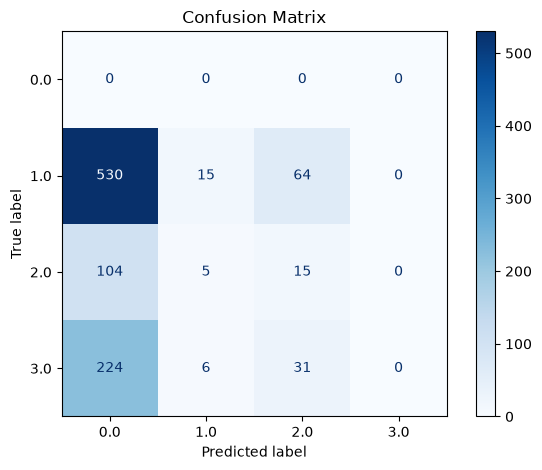

ROC curve skipped: multiclass targets are not plotted as a single ROC curve.


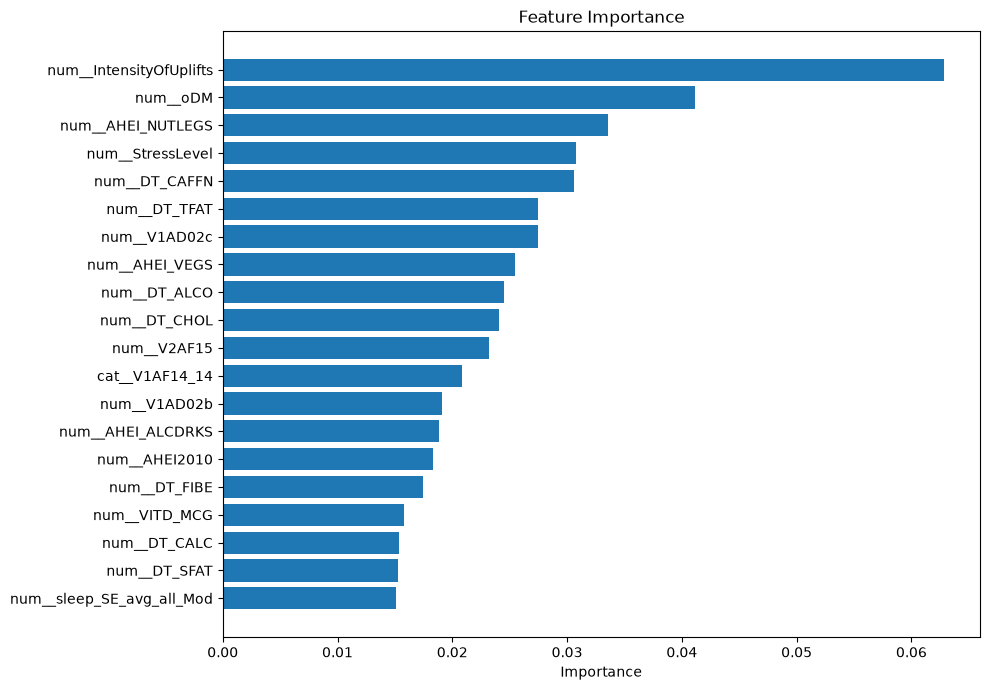

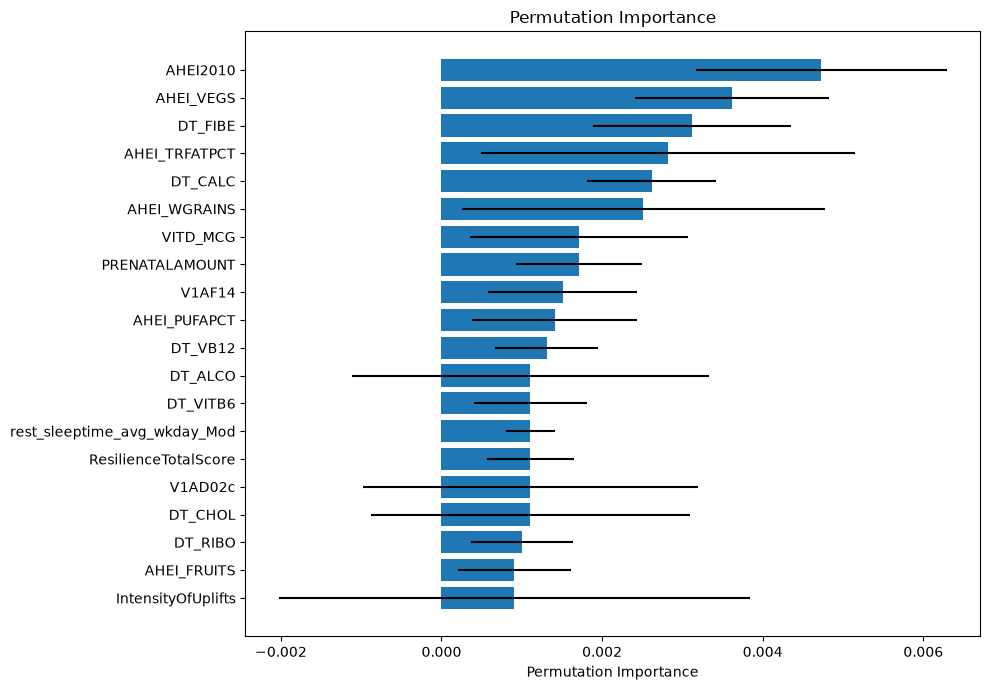

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP skipped: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.


In [11]:
# Interpretability for the XGB breastfeeding model.
# Swap xgb_model for lr_model, rf_model, or svm_model if you want a different view.
run_interpretability_suite(xgb_model, X_train, X_test, y_test, labels=[1, 2, 3], top_n=20)